In [1]:
!pip install torch matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sử dụng: {device}")

Sử dụng: cuda


In [3]:
# Transform: ToTensor() chuẩn hóa [0,255] → [0,1]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Tải MNIST
train_dataset = datasets.MNIST(
    root='./data', train=True,
    download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root='./data', train=False,
    download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.57MB/s]


In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)  # → μ
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)  # → logvar

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # x: (batch, 784)
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Reparameterization Trick: z = μ + σ × ε
        std = torch.exp(0.5 * logvar)   # σ = exp(logvar/2)
        eps = torch.randn_like(std)       # ε ~ N(0,1)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))  # output [0,1]

    def forward(self, x):
        # Flatten: (batch, 1, 28, 28) → (batch, 784)
        x_flat = x.view(-1, 784)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# Khởi tạo mô hình
model = VAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)
print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)


In [5]:
def vae_loss(x_recon, x, mu, logvar):
    """
    VAE Loss = Reconstruction Loss (BCE) + KL Divergence

    Args:
        x_recon: ảnh tái tạo, shape (batch, 784)
        x:       ảnh gốc,     shape (batch, 784)
        mu:      vector mean, shape (batch, latent_dim)
        logvar:  log variance, shape (batch, latent_dim)
    """
    # BCE Loss: so sánh từng pixel
    bce = F.binary_cross_entropy(
        x_recon, x.view(-1, 784),
        reduction='sum'
    )

    # KL Divergence: -½ Σ(1 + logvar - μ² - e^logvar)
    kld = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return bce + kld, bce, kld

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 30
train_losses = []

def train_epoch(epoch):
    model.train()
    total_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        # Forward pass
        recon, mu, logvar = model(data)

        # Tính loss
        loss, bce, kld = vae_loss(recon, data, mu, logvar)

        # Backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch}/{num_epochs}] Loss: {avg_loss:.4f}')

# Training loop
for epoch in range(1, num_epochs + 1):
    train_epoch(epoch)

Epoch [1/30] Loss: 163.7519
Epoch [2/30] Loss: 120.9759
Epoch [3/30] Loss: 114.2510
Epoch [4/30] Loss: 111.3283
Epoch [5/30] Loss: 109.5980
Epoch [6/30] Loss: 108.4146
Epoch [7/30] Loss: 107.6605
Epoch [8/30] Loss: 107.0073
Epoch [9/30] Loss: 106.4750
Epoch [10/30] Loss: 106.1142
Epoch [11/30] Loss: 105.7494
Epoch [12/30] Loss: 105.4415
Epoch [13/30] Loss: 105.1579
Epoch [14/30] Loss: 104.9206
Epoch [15/30] Loss: 104.7428
Epoch [16/30] Loss: 104.5226
Epoch [17/30] Loss: 104.3134
Epoch [18/30] Loss: 104.1970
Epoch [19/30] Loss: 104.0917
Epoch [20/30] Loss: 103.9098
Epoch [21/30] Loss: 103.7420
Epoch [22/30] Loss: 103.6527
Epoch [23/30] Loss: 103.5159
Epoch [24/30] Loss: 103.4180
Epoch [25/30] Loss: 103.3495
Epoch [26/30] Loss: 103.2023
Epoch [27/30] Loss: 103.1355
Epoch [28/30] Loss: 103.0115
Epoch [29/30] Loss: 102.9732
Epoch [30/30] Loss: 102.8591


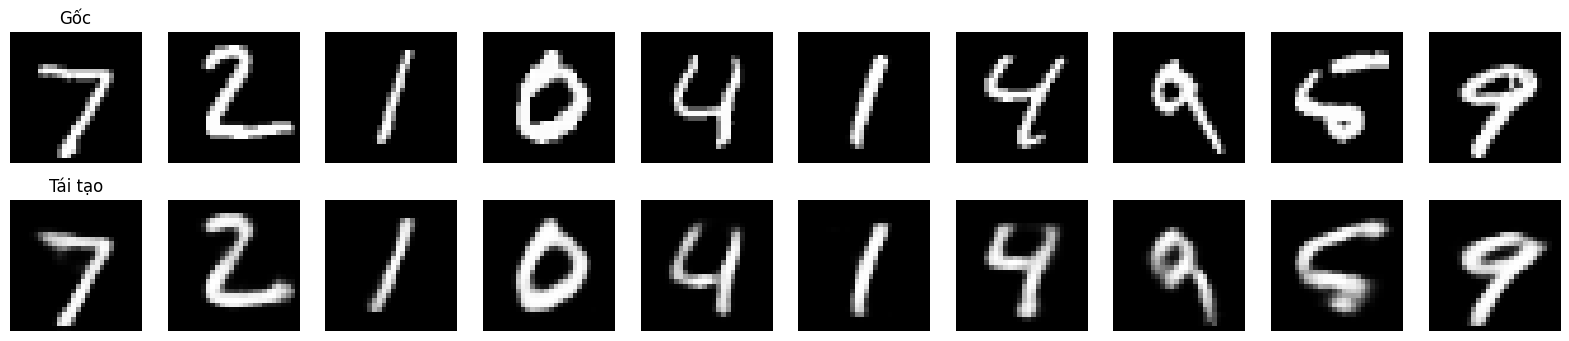

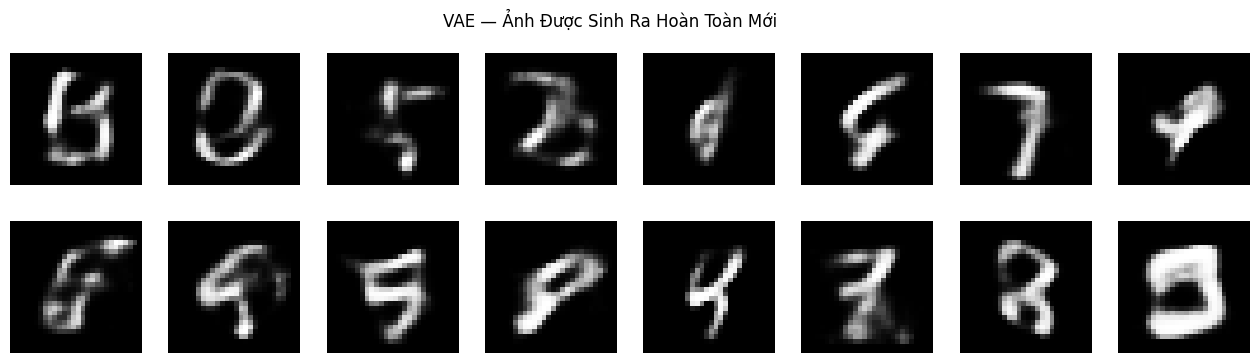

In [7]:
model.eval()
with torch.no_grad():
    # Lấy batch test đầu tiên
    sample_data, _ = next(iter(test_loader))
    sample_data = sample_data[:10].to(device)

    # Tái tạo
    recon, _, _ = model(sample_data)
    recon = recon.view(-1, 1, 28, 28).cpu()

    # Hiển thị so sánh
    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    for i in range(10):
        axes[0, i].imshow(sample_data[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_title('Gốc')
    axes[1, 0].set_title('Tái tạo')
    plt.show()

    # Generate ảnh hoàn toàn mới
    z_sample = torch.randn(16, 20).to(device)  # latent_dim=20
    generated = model.decode(z_sample).view(-1, 28, 28).cpu()

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i], cmap='gray')
        ax.axis('off')
    plt.suptitle('VAE — Ảnh Được Sinh Ra Hoàn Toàn Mới')
    plt.show()